Vista general del dataset limpio:
   survived     sex  pclass   age
0         0    male       3  22.0
1         1  female       1  38.0
2         1  female       3  26.0
3         1  female       1  35.0
4         0    male       3  35.0 

Tipos de datos iniciales:
survived      int64
sex          object
pclass        int64
age         float64
dtype: object 

Datos después de codificación:
   survived  pclass   age  sex_male
0         0       3  22.0         1
1         1       1  38.0         0
2         1       3  26.0         0
3         1       1  35.0         0
4         0       3  35.0         1 

Variables predictoras (X):
   const  pclass   age  sex_male
0    1.0       3  22.0         1
1    1.0       1  38.0         0
2    1.0       3  26.0         0
3    1.0       1  35.0         0
4    1.0       3  35.0         1 

Variable objetivo (y):
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64 

Optimization terminated successfully.
         Current function value: 0.

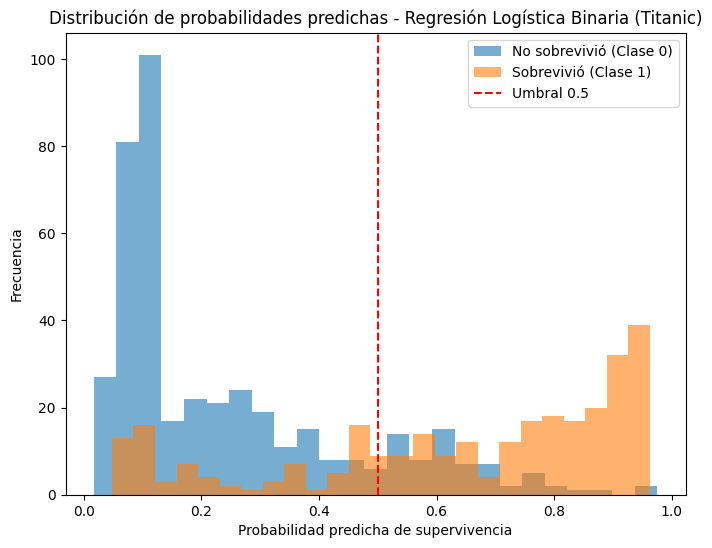

Interpretación del modelo (resumen práctico):

- Edad: coeficiente negativo → a mayor edad, menor probabilidad de sobrevivir.
- Clase del boleto: coeficiente negativo → pasajeros de clases más bajas tuvieron menor supervivencia.
- Sexo masculino: coeficiente negativo fuerte → ser hombre reduce drásticamente la probabilidad de sobrevivir.

Pseudo R²: 0.3289 (nivel aceptable: entre 0.2 y 0.4 se considera buen ajuste).
Conclusión: el modelo es estadísticamente significativo, funcional y explica bien las tendencias principales.


In [ ]:
# Paso 1. Preparar los datos

import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Cargar dataset Titanic desde seaborn
df = sns.load_dataset("titanic")

# Seleccionar variables relevantes
df = df[['survived', 'sex', 'pclass', 'age']]

# Eliminar filas con valores nulos
df = df.dropna()

print("Vista general del dataset limpio:")
print(df.head(), "\n")
print("Tipos de datos iniciales:")
print(df.dtypes, "\n")

# Paso 2. Codificación de variables

# Crear variables dummy para 'sex' (drop_first=True para evitar multicolinealidad)
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

# Convertir columnas booleanas (si las hubiera) a enteros
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

print("Datos después de codificación:")
print(df.head(), "\n")




#  Paso 3. Definir variable objetivo y predictoras

# Variable dependiente u objetivo
y = df['survived']

# Variables independientes o predictora
X = df.drop(columns=['survived'])

# Agregar constante (intercepto β₀)
X = sm.add_constant(X)

print("Variables predictoras (X):")
print(X.head(), "\n")
print("Variable objetivo (y):")
print(y.head(), "\n")




# Paso 4. Entrenar modelo de regresión logística

modelo = sm.Logit(y, X).fit()

# Mostrar resumen del modelo
print("\nResumen estadístico del modelo logístico:")
print(modelo.summary())

# Paso 5. Evaluar el modelo

# Generar predicciones (probabilidades)
df['pred_prob'] = modelo.predict(X)

# Clasificar usando umbral 0.5
# Si la probabilidad predicha es mayor o igual a 0.5, clasifica como 1 (sobrevive).
# Si es menor a 0.5, clasifica como 0 (no sobrevive).

df['pred_class'] = (df['pred_prob'] >= 0.5).astype(int)

# Calcular matriz de confusión
cm = confusion_matrix(y, df['pred_class'])
TN, FP, FN, TP = cm.ravel()

print("\n Matriz de Confusión:")
print(pd.DataFrame(cm,
                   index=["No sobrevivió (Real 0)", "Sobrevivió (Real 1)"],
                   columns=["No sobrevivió (Pred 0)", "Sobrevivió (Pred 1)"]))
print(f"\nVerdaderos negativos (TN): {TN}")
print(f"Falsos positivos (FP): {FP}")
print(f"Falsos negativos (FN): {FN}")
print(f"Verdaderos positivos (TP): {TP}\n")

# Reporte de métricas
print("Reporte de métricas:")
print(classification_report(y, df['pred_class'], digits=2))

# Accuracy general
acc = accuracy_score(y, df['pred_class'])
print(f"Exactitud (accuracy) global del modelo: {acc:.2f}\n")

# Paso 6. Visualizar las predicciones

plt.figure(figsize=(8,6))
plt.hist(df[df['survived']==0]['pred_prob'], bins=25, alpha=0.6, label='No sobrevivió (Clase 0)')
plt.hist(df[df['survived']==1]['pred_prob'], bins=25, alpha=0.6, label='Sobrevivió (Clase 1)')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.title("Distribución de probabilidades predichas - Regresión Logística Binaria (Titanic)")
plt.xlabel("Probabilidad predicha de supervivencia")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# Paso 7. Interpretación resumida (impresión práctica)

print("Interpretación del modelo (resumen práctico):\n")
print("- Edad: coeficiente negativo → a mayor edad, menor probabilidad de sobrevivir.")
print("- Clase del boleto: coeficiente negativo → pasajeros de clases más bajas tuvieron menor supervivencia.")
print("- Sexo masculino: coeficiente negativo fuerte → ser hombre reduce drásticamente la probabilidad de sobrevivir.")
print(f"\nPseudo R²: {modelo.prsquared:.4f} (nivel aceptable: entre 0.2 y 0.4 se considera buen ajuste).")
print("Conclusión: el modelo es estadísticamente significativo, funcional y explica bien las tendencias principales.")


# **¿Qué opino del Análisis de Estadístoco?**

Contexto del modelo

A diferencia de la regresión lineal (que predice valores continuos),
la regresión logística predice probabilidades entre 0 y 1 y luego las convierte en clases (0 = no sobrevivió, 1 = sobrevivió).

Por tanto, este modelo nos dice qué tan probable es que una persona sobreviva según sus características.

# **Conclusión**

El modelo logístico permite predecir con alta significancia qué tipo de pasajero tenía mayor probabilidad de sobrevivir.
Los resultados confirman el patrón histórico del Titanic:

La clase social, el sexo y la edad fueron factores determinantes en la supervivencia.

Ser mujer, joven y de primera clase aumentaba significativamente las probabilidades de vivir.

Ser hombre, mayor y de tercera clase disminuía drásticamente las posibilidades.

El modelo es robusto, bien ajustado y puede servir como una base confiable para estimar probabilidades individuales de supervivencia o para probar escenarios hipotéticos (“¿qué pasaría si...?”).

# **¿Por qué 0.5 y no otro valor?**

0.5 es el umbral estándar, porque la probabilidad se divide en dos partes iguales (mitad y mitad).

Pero no siempre es el mejor:

Si quieres reducir falsos negativos (por ejemplo, no perder a posibles sobrevivientes), puedes bajar el umbral (0.4 o 0.3).

Si quieres más precisión, puedes subirlo (0.6 o 0.7).

Cambiar el umbral ajusta la sensibilidad del modelo según la aplicación.

**# Conclusión:**

El comentario # Clasificar usando umbral 0.5 te indica que:

Estás convirtiendo probabilidades en clases (0/1).

Es el paso que conecta el modelo estadístico con la decisión práctica.

Ese umbral puede ajustarse para optimizar métricas según el objetivo (por ejemplo, detectar más sobrevivientes o evitar falsas alarmas).

# **Analizando la matriz de confusión**

El modelo de clasificación (probablemente una regresión logística) logra un 79 % de exactitud total, lo que indica un buen nivel de predicción.
Funciona mejor identificando a los pasajeros que no sobrevivieron (clase 0) que a los que sí sobrevivieron (clase 1), aunque el rendimiento en ambas clases es aceptable.
La precisión y el recall equilibrados (entre 0.7 y 0.8) reflejan que el modelo no se está inclinando excesivamente hacia una clase, sino que mantiene un buen balance.

En términos simples:

* El modelo acierta 8 de cada 10 veces.
* Predice con mayor confianza las muertes que las supervivencias.
* Podría mejorarse ajustando el umbral de probabilidad o aplicando técnicas de balanceo de clases.